In [1]:
# Cell 1 — Import required libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


## Task 1 — Data Acquisition and Exploration

The assignment requires the Breast Cancer Wisconsin (Diagnostic) dataset to be loaded, summarized, checked for data-quality issues, visualized, and discussed with respect to class imbalance.


In [2]:
# Cell 2 — Load the downloaded WDBC dataset

file_path = "data/wdbc.data"

if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"Dataset not found at '{file_path}'. "
        "Make sure wdbc.data is inside the data folder."
    )

df = pd.read_csv(file_path, header=None)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())


Dataset loaded successfully.
Shape: (569, 32)


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Cell 3 — Assign the official column structure

column_names = [
    "id",
    "diagnosis",

    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",

    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",

    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

if df.shape[1] != len(column_names):
    raise ValueError(
        f"Expected {len(column_names)} columns, but found {df.shape[1]}."
    )

df.columns = column_names

print("Column names assigned successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Column names assigned successfully.
Rows: 569
Columns: 32


In [4]:
# Cell 4 — Basic dataset inspection

print("Dataset dimensions:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nFirst 5 rows:")
display(df.head())


Dataset dimensions: (569, 32)

Data types:


,dtype
id,int64
diagnosis,str
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave_points_mean,float64



First 5 rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# Cell 5 — Summary statistics for all 30 numerical features

feature_columns = [col for col in df.columns if col not in ["id", "diagnosis"]]

summary_statistics = df[feature_columns].describe().T
summary_statistics["median"] = df[feature_columns].median()
summary_statistics["skewness"] = df[feature_columns].skew()

summary_statistics = summary_statistics[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "skewness"
    ]
]

display(summary_statistics)


,count,mean,median,std,min,25%,50%,75%,max,skewness
radius_mean,569.0,14.127292,13.370000,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000,0.942380
texture_mean,569.0,19.289649,18.840000,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000,0.650450
perimeter_mean,569.0,91.969033,86.240000,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000,0.990650
area_mean,569.0,654.889104,551.100000,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000,1.645732
smoothness_mean,569.0,0.096360,0.095870,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340,0.456324
compactness_mean,569.0,0.104341,0.092630,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540,1.190123
concavity_mean,569.0,0.088799,0.061540,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680,1.401180
concave_points_mean,569.0,0.048919,0.033500,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120,1.171180
symmetry_mean,569.0,0.181162,0.179200,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400,0.725609
fractal_dimension_mean,569.0,0.062798,0.061540,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744,1.304489


In [6]:
# Cell 6 — Check missing values and duplicate rows

missing_values = df.isnull().sum()
duplicate_count = df.duplicated().sum()

print("Total missing values:", missing_values.sum())
print("Total duplicate rows:", duplicate_count)

print("\nColumns with missing values:")
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values were found.")

if duplicate_count == 0:
    print("No duplicate rows were found.")


Total missing values: 0
Total duplicate rows: 0

Columns with missing values:


Series([], dtype: int64)

No missing values were found.
No duplicate rows were found.


In [7]:
# Cell 7 — Check the target variable

print("Unique diagnosis values:")
print(df["diagnosis"].unique())

print("\nDiagnosis counts:")
display(df["diagnosis"].value_counts())

print("\nDiagnosis percentages:")
display(
    (df["diagnosis"].value_counts(normalize=True) * 100)
    .round(2)
    .rename("percentage")
)


Unique diagnosis values:
<StringArray>
['M', 'B']
Length: 2, dtype: str

Diagnosis counts:


diagnosis
B    357
M    212
Name: count, dtype: int64


Diagnosis percentages:


diagnosis
B    62.74
M    37.26
Name: percentage, dtype: float64

### Outlier Detection

Potential outliers are identified using the standard IQR rule:

- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

The outliers are not automatically deleted because these are medical measurements and an extreme observation may still be a legitimate observation. In the preprocessing stage below, the IQR limits will be learned from the training data and used for conservative capping before standardization.


In [8]:
# Cell 8 — Detect potential outliers using the IQR method

outlier_summary = []

for column in feature_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    )

    outlier_summary.append({
        "Feature": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Potential Outliers": int(outlier_mask.sum())
    })

outlier_df = pd.DataFrame(outlier_summary)

display(
    outlier_df.sort_values(
        "Potential Outliers",
        ascending=False
    )
)


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers
13,area_se,17.850000,45.190000,27.340000,-23.160000,86.200000,65
10,radius_se,0.232400,0.478900,0.246500,-0.137350,0.848650,38
12,perimeter_se,1.606000,3.357000,1.751000,-1.020500,5.983500,38
23,area_worst,515.300000,1084.000000,568.700000,-337.750000,1937.050000,35
14,smoothness_se,0.005169,0.008146,0.002977,0.000703,0.012612,30
19,fractal_dimension_se,0.002248,0.004558,0.002310,-0.001217,0.008023,28
15,compactness_se,0.013080,0.032450,0.019370,-0.015975,0.061505,28
18,symmetry_se,0.015160,0.023480,0.008320,0.002680,0.035960,27
3,area_mean,420.300000,782.700000,362.400000,-123.300000,1326.300000,25
29,fractal_dimension_worst,0.071460,0.092080,0.020620,0.040530,0.123010,24


In [9]:
# Cell 9 — Summarize the outlier analysis

total_potential_outliers = outlier_df["Potential Outliers"].sum()
features_with_outliers = (outlier_df["Potential Outliers"] > 0).sum()

print("Total potential outlier observations across feature columns:",
      total_potential_outliers)
print("Number of feature columns containing potential outliers:",
      features_with_outliers)

print("\nTop 10 features by potential outlier count:")
display(
    outlier_df.sort_values(
        "Potential Outliers",
        ascending=False
    ).head(10)
)


Total potential outlier observations across feature columns: 608
Number of feature columns containing potential outliers: 29

Top 10 features by potential outlier count:


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers
13,area_se,17.850000,45.190000,27.340000,-23.160000,86.200000,65
10,radius_se,0.232400,0.478900,0.246500,-0.137350,0.848650,38
12,perimeter_se,1.606000,3.357000,1.751000,-1.020500,5.983500,38
23,area_worst,515.300000,1084.000000,568.700000,-337.750000,1937.050000,35
14,smoothness_se,0.005169,0.008146,0.002977,0.000703,0.012612,30
19,fractal_dimension_se,0.002248,0.004558,0.002310,-0.001217,0.008023,28
15,compactness_se,0.013080,0.032450,0.019370,-0.015975,0.061505,28
18,symmetry_se,0.015160,0.023480,0.008320,0.002680,0.035960,27
3,area_mean,420.300000,782.700000,362.400000,-123.300000,1326.300000,25
29,fractal_dimension_worst,0.071460,0.092080,0.020620,0.040530,0.123010,24


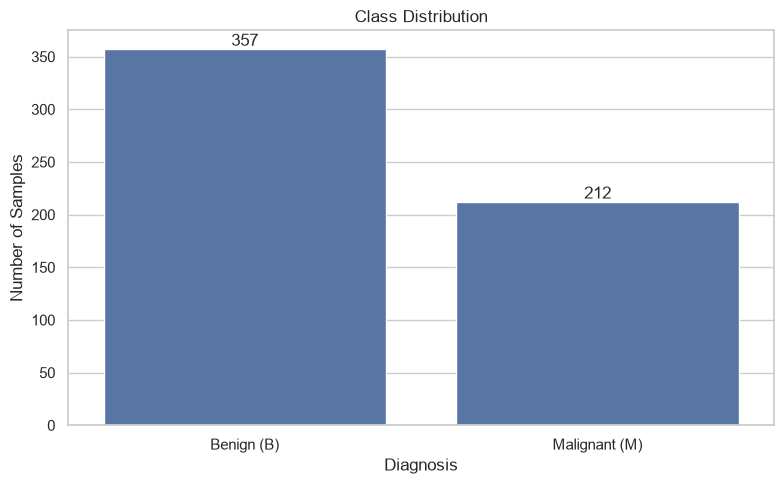

In [10]:
# Cell 10 — Class distribution visualization

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="diagnosis",
    order=["B", "M"]
)

ax.set_title("Class Distribution")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Number of Samples")

ax.set_xticklabels([
    "Benign (B)",
    "Malignant (M)"
])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


In [11]:
# Cell 11 — Class distribution percentages

class_counts = df["diagnosis"].value_counts()
class_percentages = df["diagnosis"].value_counts(normalize=True) * 100

class_distribution = pd.DataFrame({
    "Class": ["Benign", "Malignant"],
    "Count": [
        class_counts.get("B", 0),
        class_counts.get("M", 0)
    ],
    "Percentage": [
        class_percentages.get("B", 0),
        class_percentages.get("M", 0)
    ]
})

class_distribution["Percentage"] = class_distribution["Percentage"].round(2)

display(class_distribution)


,Class,Count,Percentage
0,Benign,357,62.74
1,Malignant,212,37.26


### Class Imbalance Discussion

The class distribution is not perfectly balanced. Benign cases form the larger class, while malignant cases form the smaller class.

This matters because a model could obtain a relatively high accuracy by favoring the majority class. Therefore, accuracy should not be considered alone. Precision, recall, F1-score, the confusion matrix, and ROC-AUC are also evaluated.

For a medical diagnosis problem, recall for malignant cases is particularly important because a false negative means that a malignant case was classified as benign.

Stratified sampling is used during the train-test split so that the class proportions are approximately maintained in both subsets.


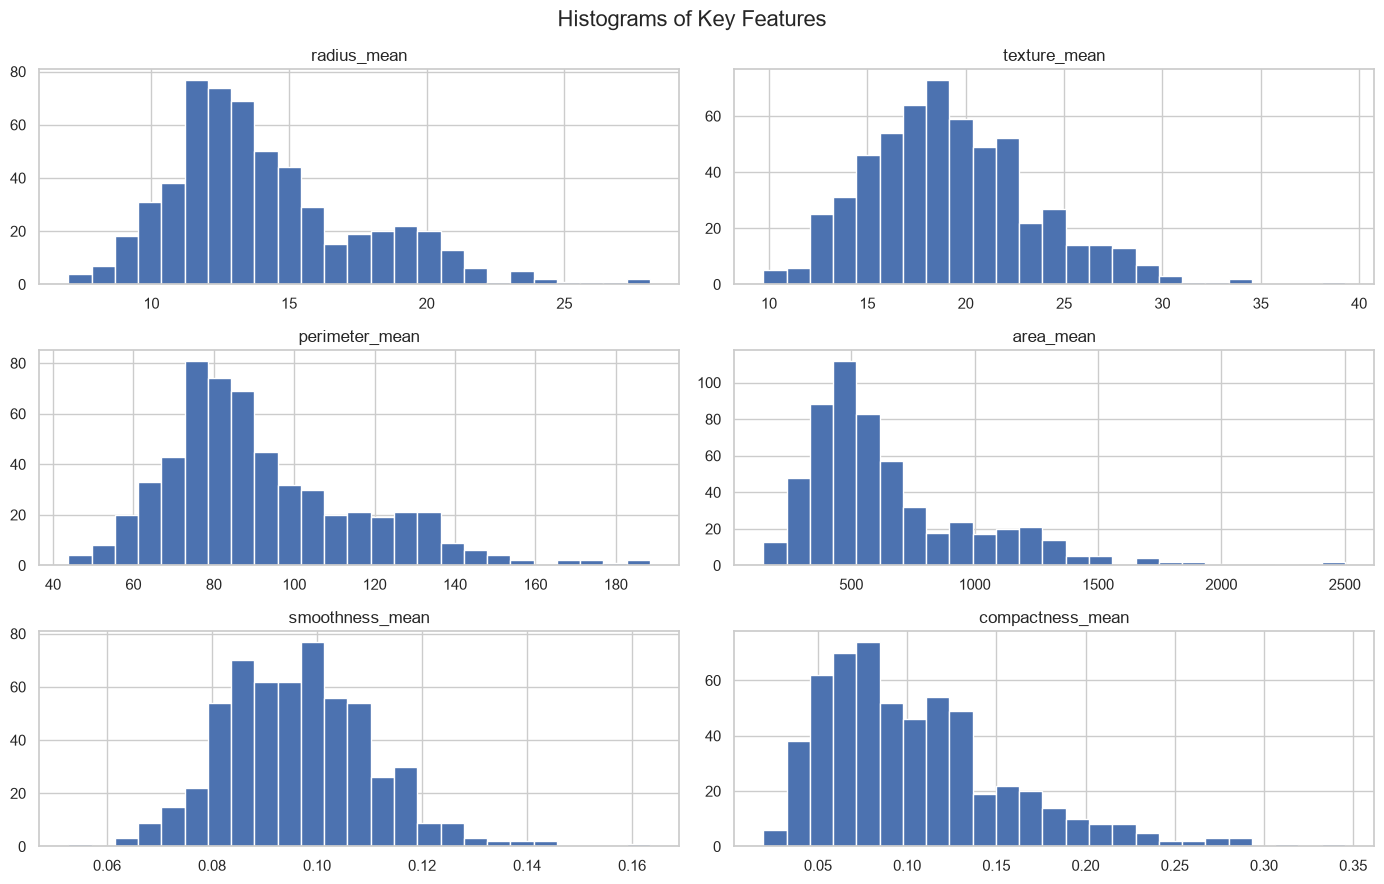

In [12]:
# Cell 12 — Histograms for key features

key_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean"
]

df[key_features].hist(
    figsize=(14, 9),
    bins=25
)

plt.suptitle(
    "Histograms of Key Features",
    fontsize=16
)

plt.tight_layout()
plt.show()


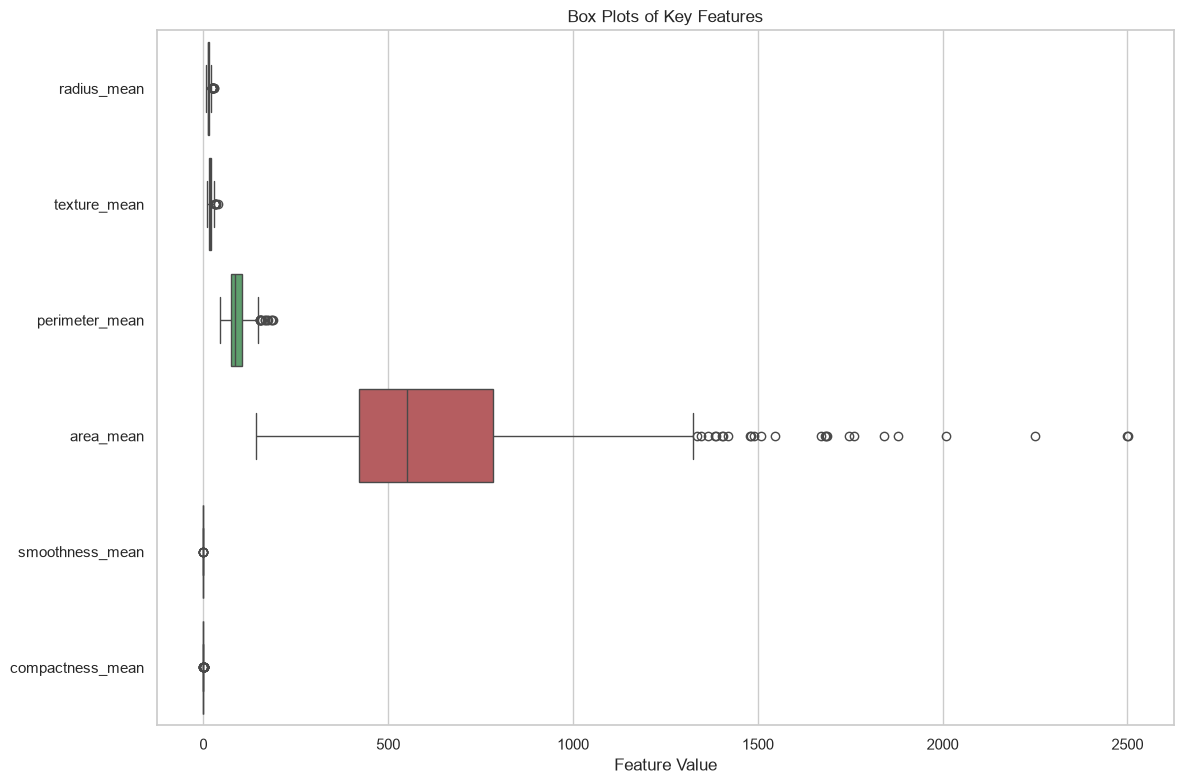

In [13]:
# Cell 13 — Box plots for key features

plt.figure(figsize=(12, 8))

sns.boxplot(
    data=df[key_features],
    orient="h"
)

plt.title("Box Plots of Key Features")
plt.xlabel("Feature Value")

plt.tight_layout()
plt.show()


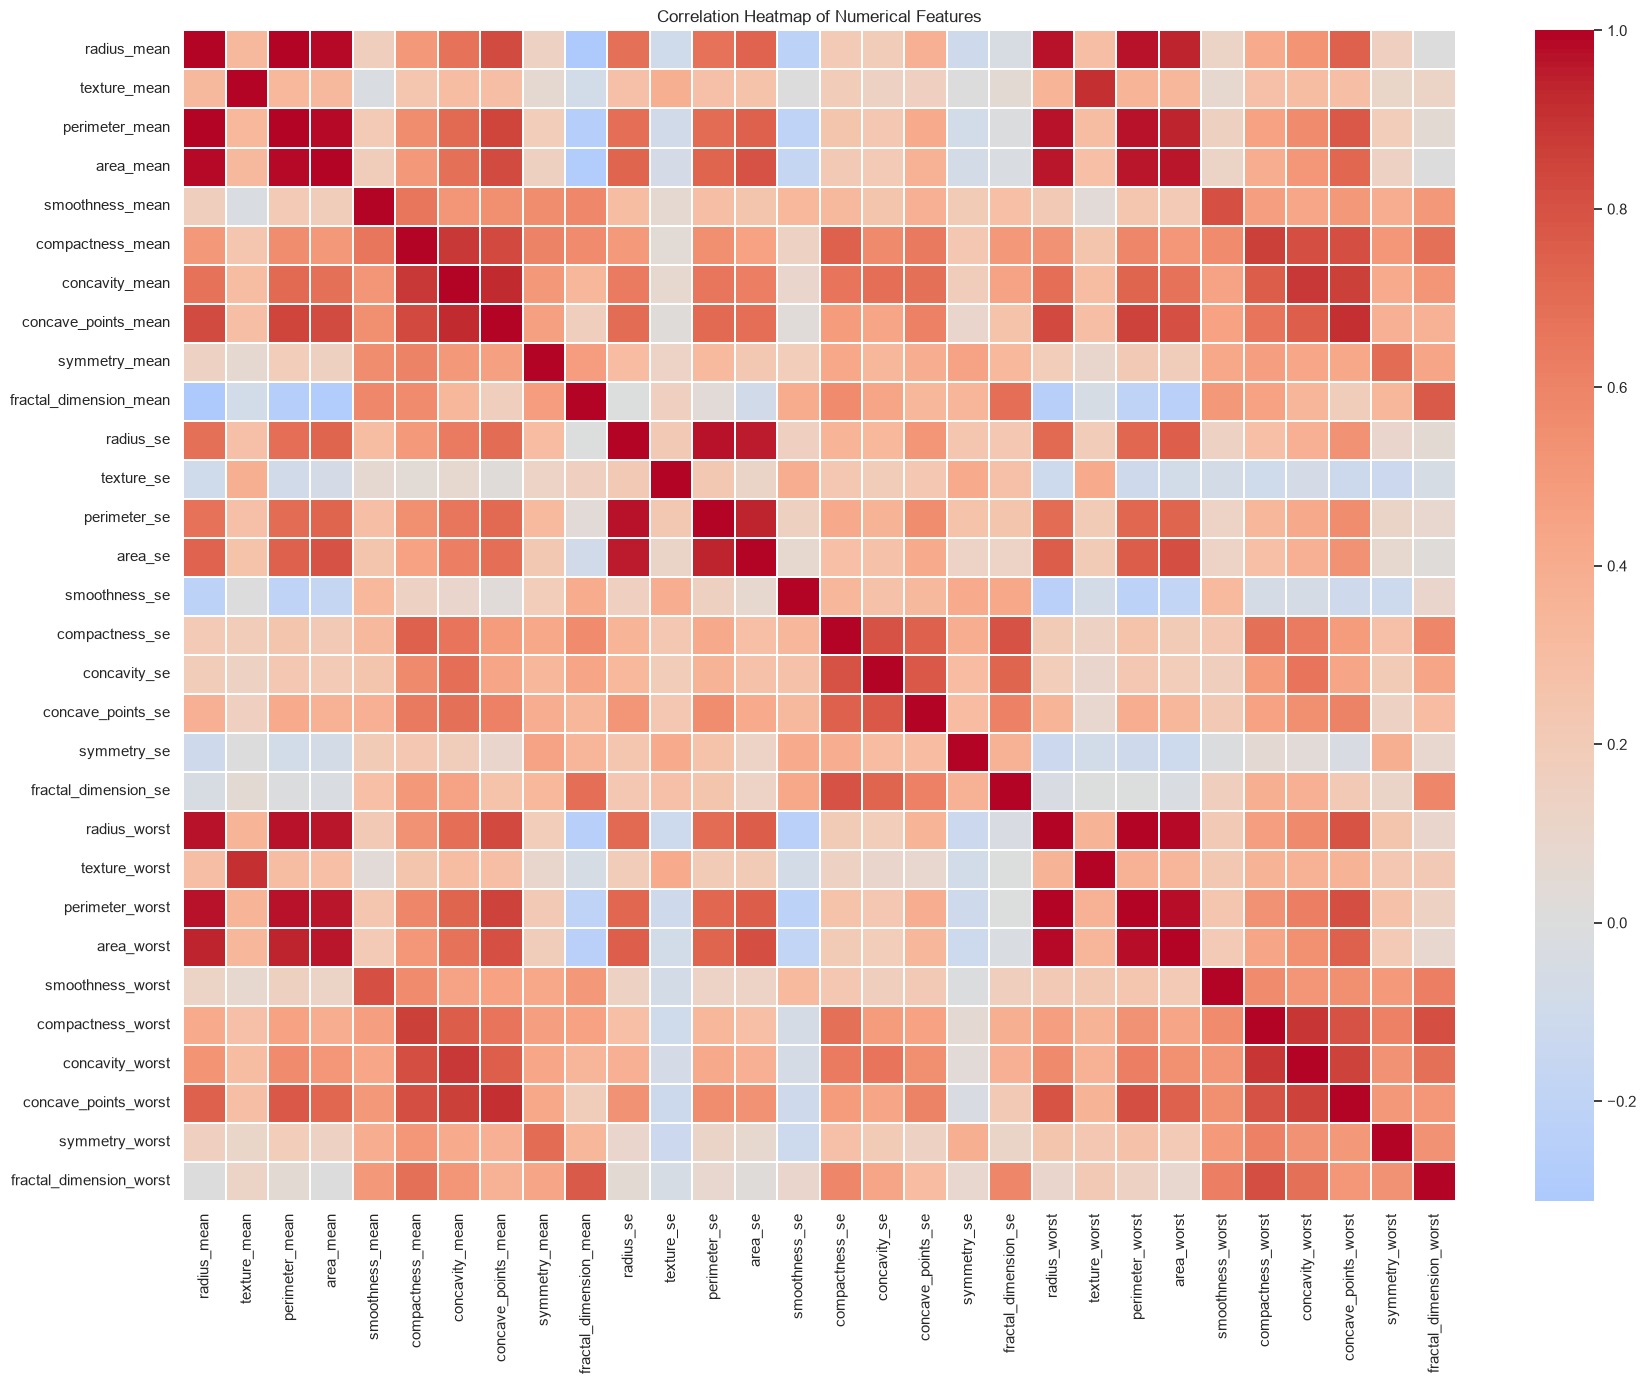

In [14]:
# Cell 14 — Correlation heatmap

correlation_matrix = df[feature_columns].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()


## Task 2 — Data Preprocessing

The target variable is encoded as binary:

- `1 = Malignant`
- `0 = Benign`

The patient ID is excluded from the predictive features because it is an identifier rather than a medical measurement.


In [15]:
# Cell 15 — Encode the target and create X/y

df["target"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

if df["target"].isnull().any():
    raise ValueError("Unexpected diagnosis value found during target encoding.")

X = df[feature_columns].copy()
y = df["target"].copy()

print("Target encoding:")
print("1 = Malignant")
print("0 = Benign")

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nEncoded target distribution:")
display(y.value_counts().sort_index())


Target encoding:
1 = Malignant
0 = Benign

Feature matrix shape: (569, 30)
Target shape: (569,)

Encoded target distribution:


target
0    357
1    212
Name: count, dtype: int64

In [16]:
# Cell 16 — Stratified 80/20 train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
display(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
display(y_test.value_counts().sort_index())


Training samples: 455
Testing samples: 114

Training class distribution:


target
0    285
1    170
Name: count, dtype: int64


Testing class distribution:


target
0    72
1    42
Name: count, dtype: int64

### Outlier Handling Before Standardization

Potential outliers identified during exploration are handled with IQR-based capping.

To avoid data leakage:

1. IQR limits are calculated using **training data only**.
2. Training values are capped at those limits.
3. The exact same training-derived limits are applied to the test set.

No test-set information is used to calculate the preprocessing thresholds.


In [17]:
# Cell 17 — Handle potential outliers with training-only IQR capping

X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

iqr_limits = {}

for column in feature_columns:
    q1 = X_train_clean[column].quantile(0.25)
    q3 = X_train_clean[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    iqr_limits[column] = (lower_bound, upper_bound)

    X_train_clean[column] = X_train_clean[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    X_test_clean[column] = X_test_clean[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Potential outliers handled using IQR-based capping.")
print("IQR thresholds were calculated from the training data only.")


Potential outliers handled using IQR-based capping.
IQR thresholds were calculated from the training data only.


In [18]:
# Cell 18 — Standardize the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

print("Standardization completed.")
print("Training matrix shape:", X_train_scaled.shape)
print("Testing matrix shape:", X_test_scaled.shape)

print("\nApproximate training mean:", X_train_scaled.mean())
print("Approximate training standard deviation:", X_train_scaled.std())


Standardization completed.
Training matrix shape: (455, 30)
Testing matrix shape: (114, 30)

Approximate training mean: 1.7763568394002505e-17
Approximate training standard deviation: 1.0


## Task 3 — Model Training and Basic Evaluation

A Logistic Regression classifier is trained on the standardized training data.


In [19]:
# Cell 19 — Train Logistic Regression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


In [20]:
# Cell 20 — Generate predictions and probabilities

y_pred = logistic_model.predict(X_test_scaled)

# Probability of the malignant class (1)
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully.")

print("\nFirst 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 malignant probabilities:")
print(np.round(y_prob[:10], 4))


Predictions generated successfully.

First 10 predictions:
[0 1 0 0 1 0 1 0 0 0]

First 10 malignant probabilities:
[2.000e-04 1.000e+00 2.550e-02 4.722e-01 5.228e-01 6.000e-04 8.040e-01
 5.000e-04 4.000e-04 7.400e-03]


In [21]:
# Cell 21 — Calculate Accuracy, Precision, Recall and F1-score

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    labels=[0, 1],
    average=None,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    labels=[0, 1],
    average=None,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    labels=[0, 1],
    average=None,
    zero_division=0
)

metrics_table = pd.DataFrame({
    "Class": ["Benign (0)", "Malignant (1)"],
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
})

print(f"Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")

display(metrics_table.round(4))


Accuracy: 0.9649 (96.49%)


,Class,Precision,Recall,F1-Score
0,Benign (0),0.9595,0.9861,0.9726
1,Malignant (1),0.9750,0.9286,0.9512


In [22]:
# Cell 22 — Classification report

print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=["Benign", "Malignant"],
        digits=4,
        zero_division=0
    )
)


              precision    recall  f1-score   support

      Benign     0.9595    0.9861    0.9726        72
   Malignant     0.9750    0.9286    0.9512        42

    accuracy                         0.9649       114
   macro avg     0.9672    0.9573    0.9619       114
weighted avg     0.9652    0.9649    0.9647       114



In [23]:
# Cell 23 — Confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

print("Confusion Matrix:")
print(cm)

TN, FP, FN, TP = cm.ravel()

print("\nTrue Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)


Confusion Matrix:
[[71  1]
 [ 3 39]]

True Negative (TN): 71
False Positive (FP): 1
False Negative (FN): 3
True Positive (TP): 39


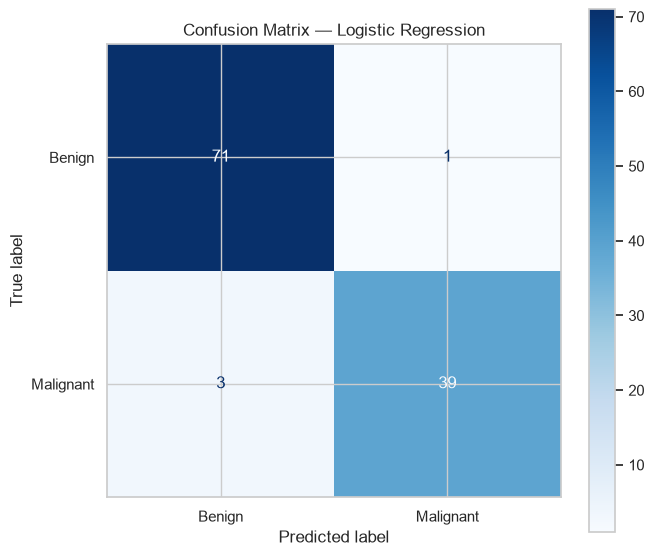

In [24]:
# Cell 24 — Visualize confusion matrix

fig, ax = plt.subplots(figsize=(7, 6))

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

display_cm.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()


In [25]:
# Cell 25 — ROC curve and AUC

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC-AUC: {auc_score:.4f}")


ROC-AUC: 0.9964


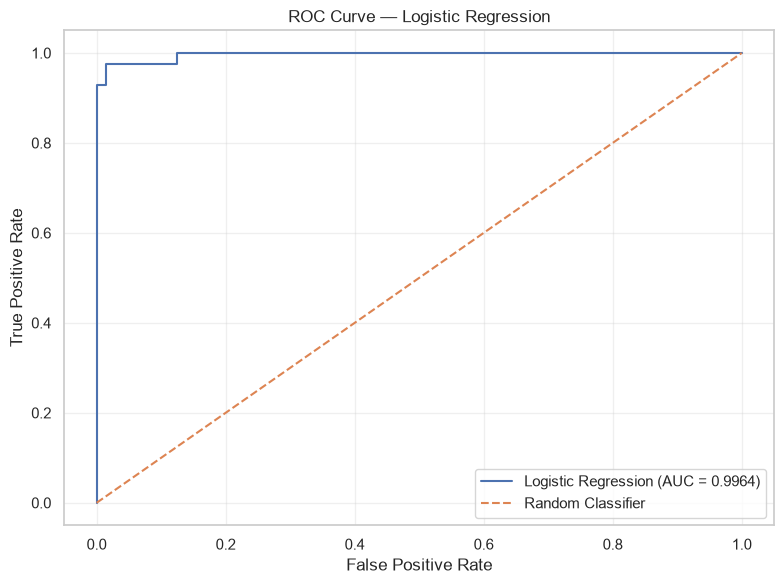

In [26]:
# Cell 26 — Plot ROC curve

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Model Interpretation

Logistic Regression coefficients describe how changes in standardized feature values are associated with the model's predicted log-odds of malignancy.

- A **positive coefficient** increases the predicted odds of malignancy as the feature increases.
- A **negative coefficient** decreases the predicted odds of malignancy as the feature increases.

Because the features are standardized, coefficient magnitudes can be compared more meaningfully across features.

The exponentiated coefficient, `exp(coefficient)`, represents the multiplicative change in the odds of malignancy associated with a one-standard-deviation increase in the feature, holding the other model features constant.


In [27]:
# Cell 27 — Logistic Regression coefficient interpretation

coefficient_table = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficient_table["Odds_Ratio"] = np.exp(
    coefficient_table["Coefficient"]
)

coefficient_table["Absolute_Coefficient"] = (
    coefficient_table["Coefficient"].abs()
)

coefficient_table = coefficient_table.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(coefficient_table.head(15).round(4))


,Feature,Coefficient,Odds_Ratio,Absolute_Coefficient
21,texture_worst,1.4646,4.3260,1.4646
13,area_se,1.1585,3.1853,1.1585
28,symmetry_worst,1.0504,2.8587,1.0504
15,compactness_se,-1.0183,0.3612,1.0183
7,concave_points_mean,0.9068,2.4765,0.9068
10,radius_se,0.8744,2.3974,0.8744
26,concavity_worst,0.8358,2.3068,0.8358
23,area_worst,0.7944,2.2130,0.7944
6,concavity_mean,0.7498,2.1166,0.7498
19,fractal_dimension_se,-0.7001,0.4966,0.7001


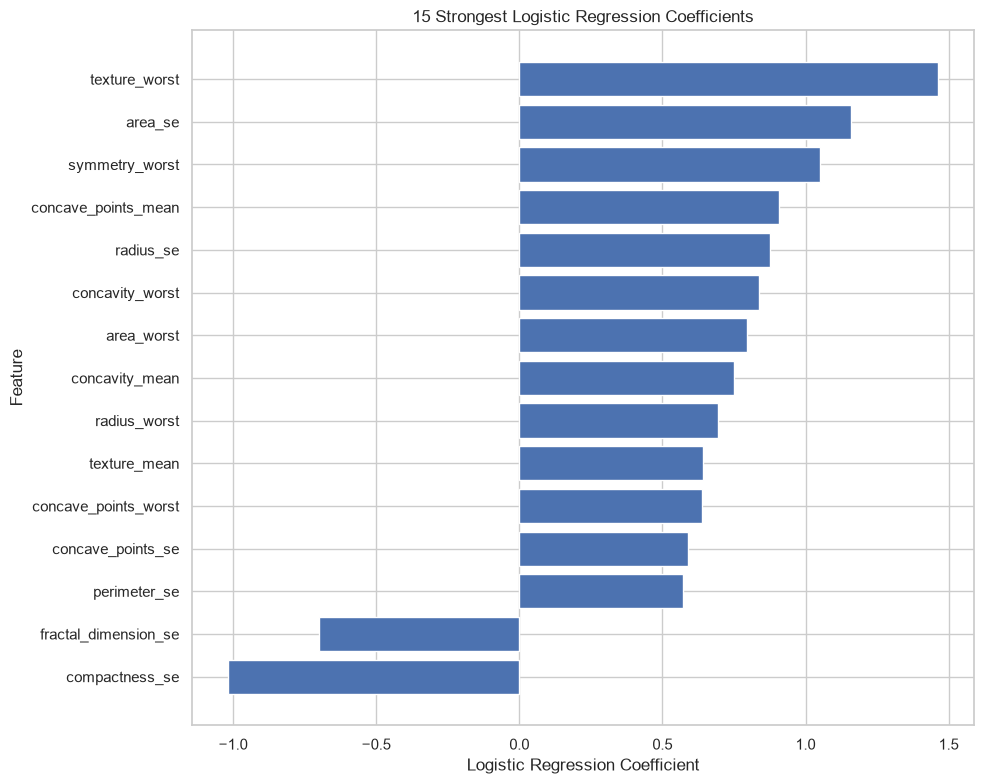

In [28]:
# Cell 28 — Visualize the 15 strongest coefficients

top_coefficients = (
    coefficient_table
    .head(15)
    .sort_values("Coefficient")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("15 Strongest Logistic Regression Coefficients")

plt.tight_layout()
plt.show()


In [29]:
# Cell 29 — Final results table

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "ROC-AUC",
        "Benign Precision",
        "Benign Recall",
        "Benign F1-Score",
        "Malignant Precision",
        "Malignant Recall",
        "Malignant F1-Score"
    ],
    "Score": [
        accuracy,
        auc_score,
        precision[0],
        recall[0],
        f1[0],
        precision[1],
        recall[1],
        f1[1]
    ]
})

display(final_results.round(4))


,Metric,Score
0,Accuracy,0.9649
1,ROC-AUC,0.9964
2,Benign Precision,0.9595
3,Benign Recall,0.9861
4,Benign F1-Score,0.9726
5,Malignant Precision,0.9750
6,Malignant Recall,0.9286
7,Malignant F1-Score,0.9512


# Interpretation of Results

The Logistic Regression model is evaluated using accuracy, precision, recall, F1-score, the confusion matrix, and ROC-AUC.

### Accuracy

Accuracy represents the proportion of test observations classified correctly. A high accuracy indicates that the model correctly classified most of the test observations, but accuracy should not be considered alone because the classes are not perfectly balanced.

### Precision

Precision measures how many observations predicted as a particular class actually belong to that class. Higher precision means fewer false-positive predictions for that class.

### Recall

Recall measures how many actual observations belonging to a class were correctly identified.

For this medical diagnosis task, **malignant-class recall is especially important**. A false negative occurs when an actually malignant case is classified as benign. Such an error could potentially delay further clinical investigation.

### F1-score

The F1-score combines precision and recall. It is useful when both types of classification errors matter.

### Confusion Matrix

The confusion matrix shows the numbers of true negatives, false positives, false negatives, and true positives. In this assignment, particular attention should be paid to the false negatives for the malignant class.

### ROC-AUC

The ROC curve evaluates the model across different classification thresholds. A higher AUC indicates better ability to distinguish between benign and malignant observations.

### Medical Diagnosis Context

The model's performance should be evaluated with special attention to malignant recall and false negatives, rather than relying only on accuracy.

A model can perform strongly on this dataset while still making clinically important errors. A model intended for real clinical use would require additional independent validation, clinical evaluation, and assessment beyond this educational assignment.

### Important Note

This Logistic Regression model is developed for the purposes of this assignment and should **not** be treated as a clinically validated diagnostic system.


In [30]:
# Cell 30 — Automatically generate a concise final interpretation

print("=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)

print(f"Accuracy:             {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"ROC-AUC:              {auc_score:.4f}")

print("\nBenign (0):")
print(f"  Precision:          {precision[0]:.4f}")
print(f"  Recall:             {recall[0]:.4f}")
print(f"  F1-Score:           {f1[0]:.4f}")

print("\nMalignant (1):")
print(f"  Precision:          {precision[1]:.4f}")
print(f"  Recall:             {recall[1]:.4f}")
print(f"  F1-Score:           {f1[1]:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nMedical interpretation:")
print(
    f"The model correctly identified {TP} malignant cases and missed {FN} "
    "malignant cases in the test set."
)

print(
    "Because false negatives can be particularly important in a medical "
    "diagnosis context, malignant recall should be considered alongside "
    "the other evaluation metrics."
)

print("=" * 70)


FINAL MODEL SUMMARY
Accuracy:             0.9649 (96.49%)
ROC-AUC:              0.9964

Benign (0):
  Precision:          0.9595
  Recall:             0.9861
  F1-Score:           0.9726

Malignant (1):
  Precision:          0.9750
  Recall:             0.9286
  F1-Score:           0.9512

Confusion Matrix:
[[71  1]
 [ 3 39]]

Medical interpretation:
The model correctly identified 39 malignant cases and missed 3 malignant cases in the test set.
Because false negatives can be particularly important in a medical diagnosis context, malignant recall should be considered alongside the other evaluation metrics.


# Conclusion

This notebook completed the required Lab 4 workflow:

- Loaded the Breast Cancer Wisconsin (Diagnostic) dataset.
- Calculated summary statistics for all numerical features.
- Checked missing values and duplicate records.
- Detected potential outliers using the IQR method and handled them using training-only IQR capping.
- Visualized key features with histograms and box plots.
- Created a correlation heatmap.
- Examined class distribution and discussed class imbalance.
- Encoded the diagnosis as a binary target (`1 = Malignant`, `0 = Benign`).
- Performed an 80/20 stratified train-test split.
- Standardized the features using `StandardScaler`.
- Trained a Logistic Regression classifier.
- Evaluated accuracy, precision, recall, F1-score, confusion matrix, ROC curve and AUC.
- Interpreted Logistic Regression coefficients and odds ratios.
- Discussed the results in the context of medical diagnosis.

The reported numerical results in the notebook are generated dynamically when the notebook is run, so they will always correspond to the preprocessing and model actually executed.
